# Importacion de la librerias

In [1]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.utils import shuffle
from sklearn.metrics import precision_score, recall_score, classification_report
from joblib import Parallel, delayed

# Cargar los datos

In [2]:
data=('fraud_detection_dataset.csv')

In [3]:
df=pd.read_csv(data)

In [175]:
df.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
0,2023-12-15 02:48:24,3cbf0b8a-c799-4c0e-9782-89272ab8fa2b,998.99,Grantfurt,Mobile,0,56,42524.98,8394.05,655
1,2023-10-30 11:08:37,3675ed98-6863-4bae-b089-6f0db2df006b,241.39,Kimberlychester,Tablet,0,52,69884.04,28434.06,395
2,2023-11-21 05:19:35,4be1043f-20ee-4ac5-a689-b25c6a1de50c,836.42,Gutierrezville,Desktop,0,58,126953.62,39121.78,496
3,2023-11-07 00:03:25,cad0b3c9-099f-479b-8043-6d5ecb4e1467,612.74,Markside,Desktop,0,19,128650.70,39652.48,612
4,2023-04-02 14:12:23,b6ebea7d-ba62-41d7-b042-3978a23fef8b,135.55,Anthonyshire,Tablet,0,59,102020.39,7439.81,302


# Analisis exploratorio (Eda)

- timestamp: The date and time of the transaction / marca de tiempo. 
- user_id: A unique identifier for each user / la id de usuario.
- amount: The transaction amount in currency / cantidad transacciones recurrentes.
- location: The location where the transaction occurred (city)/ la localicacion de transacciones.
- device_type: The type of device used for the transaction (e.g., Desktop, Mobile, Tablet) / tipo de dispositivo.
- age: The age of the user / la edad del usuario.
- income: The income of the user / ingreso del usuario .
- debt: The debt amount associated with the user / deuda del usuario.
- credit_score: The credit score of the user / puntuacion del credito del usuario  .
- is_fraud: Binary indicator (0 or 1) representing whether the transaction is fraudulent (1) or legitimate (0) / ls marca si es fraude o legitima.

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   timestamp     object 
 1   user_id       object 
 2   amount        float64
 3   location      object 
 4   device_type   object 
 5   is_fraud      int64  
 6   age           int64  
 7   income        float64
 8   debt          float64
 9   credit_score  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 152.6+ MB


In [177]:
print('datos vacios', df.isnull().sum().sum())

datos vacios 0


In [178]:
print("conjunto de datos: \n", df.shape)

conjunto de datos: 
 (2000000, 10)


In [179]:
df.describe()

,amount,is_fraud,age,income,debt,credit_score
count,2.000000e+06,2000000.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.751680e+03,0.5,4.400430e+01,8.502099e+04,2.498404e+04,5.747856e+02
std,1.504160e+03,0.5,1.529754e+01,3.753201e+04,1.444005e+04,1.591240e+02
min,1.000000e+01,0.0,1.800000e+01,2.000009e+04,4.000000e-02,3.000000e+02
25%,5.043400e+02,0.0,3.100000e+01,5.253058e+04,1.246551e+04,4.370000e+02
50%,1.000005e+03,0.5,4.400000e+01,8.503287e+04,2.498093e+04,5.750000e+02
75%,2.996710e+03,1.0,5.700000e+01,1.175375e+05,3.748029e+04,7.130000e+02
max,4.999990e+03,1.0,7.000000e+01,1.500000e+05,4.999998e+04,8.500000e+02


In [303]:
df.groupby('is_fraud').size()

is_fraud
0    1000000
1    1000000
dtype: int64

In [181]:
df.groupby('age').size()

age
18    37696
19    37902
20    37713
21    37944
22    37841
23    37455
24    37728
25    37641
26    37578
27    37649
28    37899
29    37582
30    37914
31    37764
32    37597
33    37446
34    37771
35    37941
36    37597
37    37782
38    37500
39    37851
40    37947
41    37753
42    37628
43    37488
44    37608
45    38022
46    37468
47    38189
48    37590
49    37349
50    37809
51    37936
52    37763
53    37766
54    37630
55    37991
56    37768
57    37733
58    37565
59    37906
60    37764
61    37853
62    38028
63    37647
64    37671
65    37714
66    37754
67    37935
68    37746
69    37613
70    37575
dtype: int64

In [15]:
#

# Preparacion de los datos 

In [64]:
df2=df.copy()

In [65]:
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = df2['timestamp'].dt.strftime('%d/%m/%Y')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')

df2 = df2.sort_values('timestamp')

In [55]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000000 entries, 122783 to 1809779
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   timestamp     datetime64[ns]
 1   user_id       object        
 2   amount        float64       
 3   location      object        
 4   device_type   object        
 5   is_fraud      int64         
 6   age           int64         
 7   income        float64       
 8   debt          float64       
 9   credit_score  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 167.8+ MB


In [56]:
df2.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
122783,2023-03-01 14:27:00,b1154e8a-fb91-4662-b35b-510f249b02a6,880.61,Sandrabury,Desktop,0,67,49737.67,21891.11,319
424592,2023-03-01 14:27:34,c9da94cb-c209-4bef-a8b9-17039ce6bd32,975.28,Javierfurt,Desktop,0,60,139635.72,23239.11,544
511371,2023-03-01 14:27:56,cd05ec0f-7929-4a0b-81f8-e0b0c6fd05ca,700.97,Nguyenberg,Tablet,0,45,103432.44,5656.16,391
679307,2023-03-01 14:30:13,3ffa2cd6-d2b3-43be-8aa1-75394e5a24d4,196.35,Lake Ashlee,Mobile,0,70,140887.09,1433.18,776
700737,2023-03-01 14:30:21,8a6ae893-c740-42cc-9732-e37555bdb5b7,977.56,Alvarezhaven,Tablet,0,20,97017.12,5497.52,494


In [66]:
freq_min = '1min'
feature_columns=['amount','age','income','debt','credit_score','is_fraud']
# df2_agrupado = df2.groupby('timestamp')[feature_columns].agg(['mean', 'std'])
df2_agrupado = df2.groupby(pd.Grouper(key='timestamp', freq=freq_min))[feature_columns].agg(['mean', 'std'])

df2_agrupado.columns = [
    f'{agg_type.upper()}_{col}' for col, agg_type in df2_agrupado.columns
]

# df2_agrupado.reset_index(inplace=True)

print(df2_agrupado.shape)
df2_agrupado.head()

# Ejemplo: si usas frecuencias de tiempo, intenta algo más granular
# df2['timestamp'] = pd.to_datetime(df2['timestamp'])
# df2_agrupado2 = df2.groupby(pd.Grouper(key='timestamp', freq='1min')).agg(...)

(525949, 12)


,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud
timestamp,,,,,,,,,,,,
2023-03-01 14:27:00,852.286667,139.331089,57.333333,11.239810,97601.943333,45231.746230,16928.793333,9785.625821,418.0,114.904308,0.00,0.0
2023-03-01 14:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:30:00,1557.462500,2032.347968,40.500000,22.308444,118672.380000,27867.800779,13227.355000,18239.762965,579.5,174.435279,0.25,0.5
2023-03-01 14:31:00,522.723333,422.142752,48.666667,24.131584,50904.076667,45575.499283,33443.020000,24525.175519,657.0,217.000000,0.00,0.0


In [67]:
df2_agrupado.head()

,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud
timestamp,,,,,,,,,,,,
2023-03-01 14:27:00,852.286667,139.331089,57.333333,11.239810,97601.943333,45231.746230,16928.793333,9785.625821,418.0,114.904308,0.00,0.0
2023-03-01 14:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:30:00,1557.462500,2032.347968,40.500000,22.308444,118672.380000,27867.800779,13227.355000,18239.762965,579.5,174.435279,0.25,0.5
2023-03-01 14:31:00,522.723333,422.142752,48.666667,24.131584,50904.076667,45575.499283,33443.020000,24525.175519,657.0,217.000000,0.00,0.0


In [68]:
print('datos vacios', df2_agrupado.isnull().sum().sum())

datos vacios 408060


In [69]:
# Interpolar usando el tiempo (ahora que 'timestamp' es el DatetimeIndex)
df2_agrupado = df2_agrupado.interpolate(method='time')

In [70]:
# Para STD NaN se dejan en 0
cols_std = [c for c in df2_agrupado.columns if 'STD' in c]
df2_agrupado[cols_std] = df2_agrupado[cols_std].fillna(0)

# Para Mean, es mejor interpolar o usar la mediana.
cols_mean = [c for c in df2_agrupado.columns if 'MEAN' in c]
df2_agrupado[cols_mean] = df2_agrupado[cols_mean].interpolate(method='time')

#despues de interpolar, resetear el índice de 'timestamp'
df2_agrupado = df2_agrupado.reset_index()

In [71]:
# Feature Engineering
# ¿Es el ingreso de este minuto muy diferente al de los últimos n minutos?
df2_agrupado['rolling_mean'] = df2_agrupado['MEAN_amount'].rolling(window=10, min_periods=1).mean()
df2_agrupado['ratio_actual_rolling'] = df2_agrupado['MEAN_amount'] / df2_agrupado['rolling_mean']

# Si después de esto queda algún NaN (por división por cero), rellena con 1
# (un ratio de 1 significa que el valor actual es igual al promedio)
df2_agrupado['ratio_actual_rolling'] = df2_agrupado['ratio_actual_rolling'].fillna(1)

In [72]:
df2_agrupado.head()

,timestamp,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud,rolling_mean,ratio_actual_rolling
0,2023-03-01 14:27:00,852.286667,139.331089,57.333333,11.239810,97601.943333,45231.746230,16928.793333,9785.625821,418.000000,114.904308,0.000000,0.000000,852.286667,1.000000
1,2023-03-01 14:28:00,1087.345278,770.336716,51.722222,14.929355,104625.422222,39443.764413,15694.980556,12603.671535,471.833333,134.747965,0.083333,0.166667,969.815972,1.121187
2,2023-03-01 14:29:00,1322.403889,1401.342342,46.111111,18.618899,111648.901111,33655.782596,14461.167778,15421.717250,525.666667,154.591622,0.166667,0.333333,1087.345278,1.216177
3,2023-03-01 14:30:00,1557.462500,2032.347968,40.500000,22.308444,118672.380000,27867.800779,13227.355000,18239.762965,579.500000,174.435279,0.250000,0.500000,1204.874583,1.292635
4,2023-03-01 14:31:00,522.723333,422.142752,48.666667,24.131584,50904.076667,45575.499283,33443.020000,24525.175519,657.000000,217.000000,0.000000,0.000000,1068.444333,0.489238


In [73]:
print('datos vacios', df2_agrupado.isnull().sum().sum())

datos vacios 0


In [74]:
df2_agrupado.describe()

,timestamp,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud,rolling_mean,ratio_actual_rolling
count,525949,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000
mean,2023-08-31 05:20:59.999998208,1751.332230,1357.678949,44.002725,14.125113,85039.563182,34692.437366,24988.387540,13334.287227,574.859068,146.916871,0.499857,0.446714,1751.323075,1.000443
min,2023-03-01 14:27:00,10.000000,0.000000,18.000000,0.000000,20001.940000,0.098995,1.630000,0.374767,300.000000,0.000000,0.000000,0.000000,654.826667,0.005081
25%,2023-05-31 21:54:00,1118.513333,924.201123,38.333333,10.526158,71073.122500,25719.427172,19606.733750,9878.789612,515.333333,108.894444,0.333333,0.447214,1555.751383,0.655644
50%,2023-08-31 05:21:00,1693.938182,1431.374697,44.000000,14.430870,85033.082500,35414.691801,24970.054000,13620.776133,574.750000,150.051903,0.500000,0.534522,1742.485929,0.972398
75%,2023-11-30 12:48:00,2283.562500,1798.072998,49.700000,17.796067,99013.376500,43780.243267,30388.367143,16827.564520,634.500000,185.355245,0.666667,0.577350,1937.011767,1.296663
max,2024-02-29 20:15:00,4999.990000,3521.313989,70.000000,36.769553,149999.520000,91790.139378,49999.930000,35238.411882,850.000000,388.908730,1.000000,0.707107,3175.325967,4.076138
std,NaN,880.478346,633.365120,8.969118,5.692662,21973.374393,13984.591361,8463.926972,5378.988806,93.277962,59.350951,0.292808,0.219165,284.049687,0.481594


In [99]:
features=['MEAN_is_fraud','timestamp','MEAN_amount','STD_amount','MEAN_age','STD_age','MEAN_income','STD_income','MEAN_debt'
          ,'STD_debt','MEAN_credit_score','STD_credit_score','ratio_actual_rolling']

# shuffle para barajar
df2_agrupado0 = df2_agrupado[features]
df2_agrupado0 = shuffle(df2_agrupado, random_state=42)

In [100]:
df2_agrupado0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525949 entries, 382619 to 121958
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   timestamp             525949 non-null  datetime64[ns]
 1   MEAN_amount           525949 non-null  float64       
 2   STD_amount            525949 non-null  float64       
 3   MEAN_age              525949 non-null  float64       
 4   STD_age               525949 non-null  float64       
 5   MEAN_income           525949 non-null  float64       
 6   STD_income            525949 non-null  float64       
 7   MEAN_debt             525949 non-null  float64       
 8   STD_debt              525949 non-null  float64       
 9   MEAN_credit_score     525949 non-null  float64       
 10  STD_credit_score      525949 non-null  float64       
 11  MEAN_is_fraud         525949 non-null  float64       
 12  STD_is_fraud          525949 non-null  float64       
 13 

# Entrenamiento del Isolation Forest

In [139]:
# Parametros
n_estimators = 500  # N_árboles
# sample_size = 256  # Número de instancias usadas para entrenar cada árbol
sample_size = 128  # Número de instancias usadas para entrenar cada árbol
# contamination = 0.20  # Proporción esperada de anomalías
contamination = 0.50  # Proporción esperada de anomalías

In [140]:
# Seleccionar variables
features = df2_agrupado0.drop(['timestamp','MEAN_is_fraud','STD_is_fraud','rolling_mean'], axis=1)

# Entrenar el modelo Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                             contamination=contamination,
                             max_samples=sample_size,
                             bootstrap=True,  # Añade aleatoriedad para evitar el "masking"
                             random_state=42,
                             n_jobs=-1 
                            )
iso_forest.fit(features)

IsolationForest(bootstrap=True, contamination=0.5, max_samples=128,
                n_estimators=500, n_jobs=-1, random_state=42)

In [141]:
print('1 indica una instancia normal y -1 indica una anomalía')

df2_agrupado0['anomaly_score'] = iso_forest.decision_function(features)
df2_agrupado0['anomaly'] = iso_forest.predict(features)

df2_agrupado0['anomaly'].value_counts()

1 indica una instancia normal y -1 indica una anomalía


anomaly
 1    262975
-1    262974
Name: count, dtype: int64

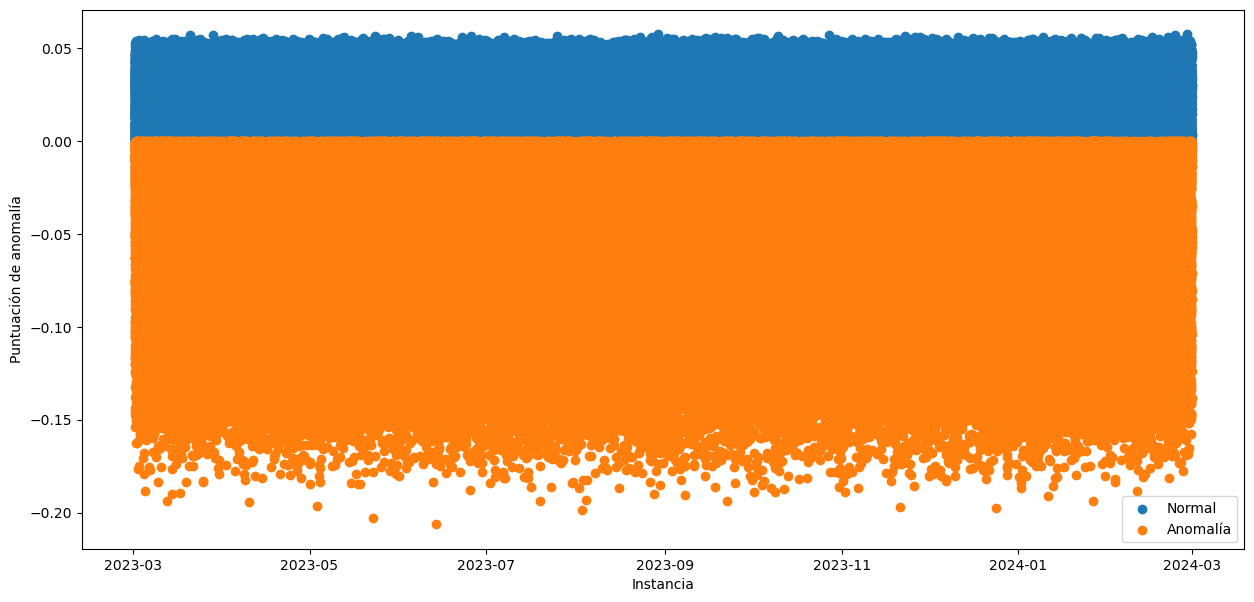

In [142]:
# Visualization of the results
plt.figure(figsize=(15, 7))

# Plot normal instances
normal = df2_agrupado0[df2_agrupado0['anomaly'] == 1]
plt.scatter(normal['timestamp'], normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = df2_agrupado0[df2_agrupado0['anomaly'] == -1]
plt.scatter(anomalies['timestamp'], anomalies['anomaly_score'], label='Anomalía')

plt.xlabel("Instancia")
plt.ylabel("Puntuación de anomalía")
plt.legend()
plt.show()

### KernelSHAP

In [143]:
df_limpio = df2_agrupado0.select_dtypes(include=['number']).astype('float64')

# explainer = shap.Explainer(iso_forest, df_limpio) 

# Seleccionar al azar n instancias normales, y todas las n de anomalías
normal_sample = np.random.choice(normal.index,size=850,replace=False)
sample = np.append(anomalies.index,normal_sample)

# Tomar una sub-muestra de 1000 normales y 1000 anomalías para el gráfico
# Suponiendo que 'sample' son tus índices
sub_sample = np.random.choice(sample, 5000, replace=False)
# shap_values_sub = explainer(features.iloc[sub_sample])
print(f'samples principales: {len(sample)}')
print(f'sub_samples : {len(sub_sample)}')

samples principales: 263824
sub_samples : 5000


In [144]:
# Uso de la puntuación de anomalía y KernelSHAP

# explainer = shap.Explainer(iso_forest.decision_function, features)
# shap_values = explainer(features.iloc[sample])



# # Configura el explainer
# explainer = shap.Explainer(iso_forest.decision_function, features)

# # Define una función para procesar cada muestra
# def compute_shap(row):
#     return explainer(row)

# # Ejecuta en paralelo sobre tu selección de muestras (sample)
# # n_jobs=-1 usará todos tus núcleos
# shap_values_list = Parallel(n_jobs=-1)(
#     delayed(compute_shap)(features.iloc[[i]]) for i in sample
# )


# TreeExplainer es nativo para modelos de árboles y mucho más eficiente
explainer = shap.TreeExplainer(iso_forest)

# Calcula los valores para todo el subset de una vez
# shap_values = explainer(features.iloc[sample])
shap_values = explainer(features.iloc[sub_sample])

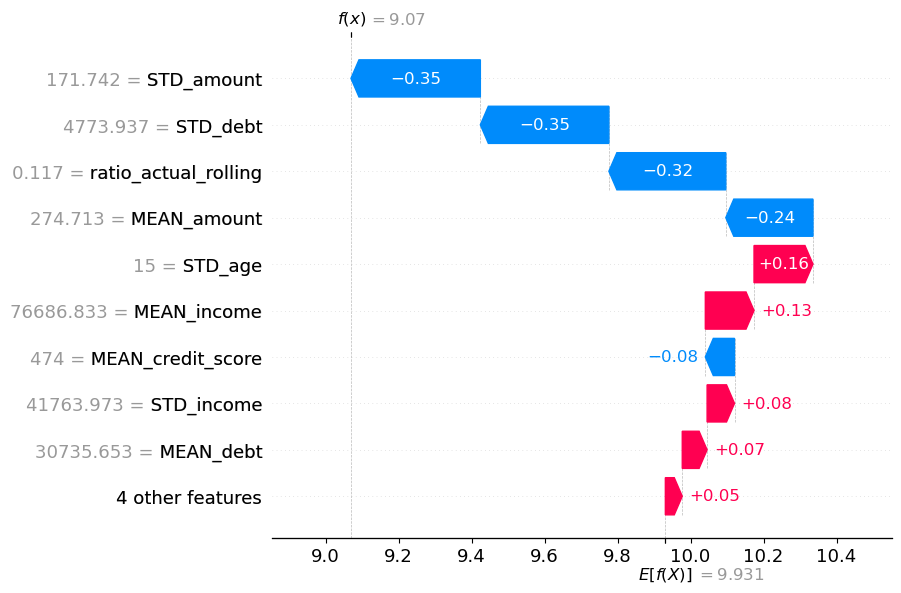

In [145]:
# Gráfico de cascada de una anomalía
shap.plots.waterfall(shap_values[0])

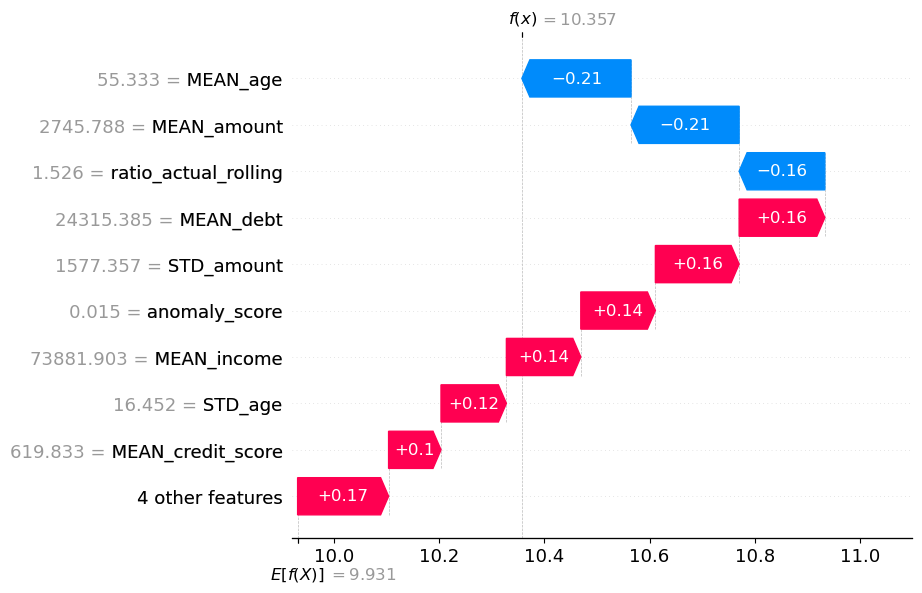

In [146]:
# Gráfico de cascada para una instancia normal
shap.plots.waterfall(shap_values[100])

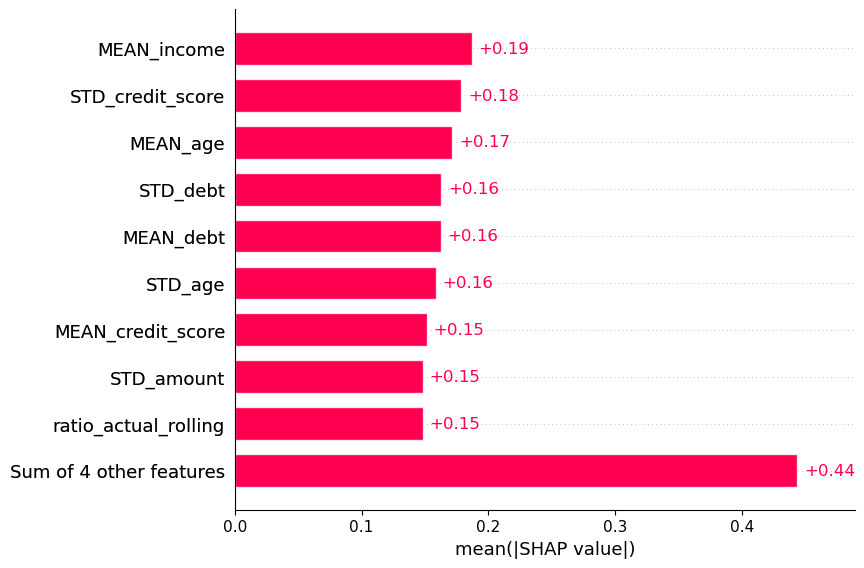

In [147]:
# Gráfico de medias de SHAP Plot
shap.plots.bar(shap_values)

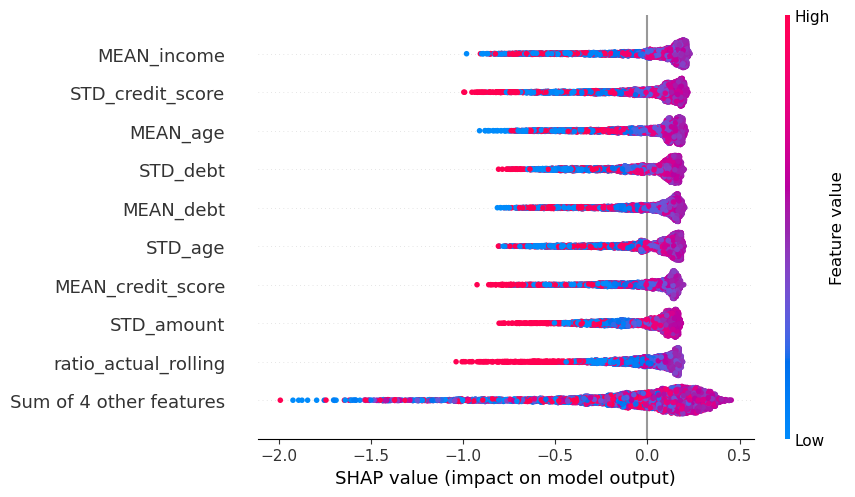

In [148]:
# Gráfico Beeswarm
shap.plots.beeswarm(shap_values)

In [149]:
print('df features')
print(features.info())
print('df2_agrupado0')
print(df2_agrupado0.info())

df features
<class 'pandas.core.frame.DataFrame'>
Index: 525949 entries, 382619 to 121958
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MEAN_amount           525949 non-null  float64
 1   STD_amount            525949 non-null  float64
 2   MEAN_age              525949 non-null  float64
 3   STD_age               525949 non-null  float64
 4   MEAN_income           525949 non-null  float64
 5   STD_income            525949 non-null  float64
 6   MEAN_debt             525949 non-null  float64
 7   STD_debt              525949 non-null  float64
 8   MEAN_credit_score     525949 non-null  float64
 9   STD_credit_score      525949 non-null  float64
 10  ratio_actual_rolling  525949 non-null  float64
 11  anomaly_score         525949 non-null  float64
 12  anomaly               525949 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 56.2 MB
None
df2_agrupado0
<class 'pandas.core.frame.

In [150]:
len(y_pred)

525949

In [151]:
# df2_agrupado0['anomaly'] = iso_forest.predict(features)

# valor de fraude real en el df
y_true = (df2_agrupado0['MEAN_is_fraud']).astype(int)
# y_true = df2_agrupado0['MEAN_is_fraud']

# Ajustar formato para evaluación: 1 para anomalía, 0 para normal
y_pred = [1 if x == -1 else 0 for x in df2_agrupado0['anomaly']]

# Generar reporte (asumiendo que tienes 'y_true')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

              precision    recall  f1-score   support

      Normal       0.97      0.56      0.71    459119
    Anomalía       0.22      0.88      0.36     66830

    accuracy                           0.60    525949
   macro avg       0.60      0.72      0.53    525949
weighted avg       0.87      0.60      0.66    525949



In [152]:
print(y_true.value_counts())

MEAN_is_fraud
0    459119
1     66830
Name: count, dtype: int64


### Por RandomForest

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


X_shuffled=features
y_shuffled=(df2_agrupado0['MEAN_is_fraud']).astype(int)

# Divide tus datos (X son tus features, y es tu columna de 'anomalia' 0 o 1)
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.3)

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    137792
           1       0.92      0.82      0.87     19993

    accuracy                           0.97    157785
   macro avg       0.95      0.90      0.93    157785
weighted avg       0.97      0.97      0.97    157785

